In [7]:
import pandas as pd
import numpy as np

# 1. อ่านไฟล์ Ice.csv โดยระบุว่า "ไม่มีหัวตาราง" และตั้งชื่อใหม่เอง
df = pd.read_csv('/content/sample_data/Ice.csv', names=['timestamp', 'Compass Heading (0-360)'])

# 2. ดูข้อมูล 20 แถวแรก
print("ข้อมูลตั้งต้นจากไฟล์ Ice.csv:")
print(df.head(20))

ข้อมูลตั้งต้นจากไฟล์ Ice.csv:
       timestamp Compass Heading (0-360)
0   1.540892e+09              271.345215
1   1.540892e+09              273.473145
2   1.540892e+09              275.623413
3   1.540892e+09               23.121687
4   1.540892e+09               21.495575
5   1.540892e+09               22.871792
6   1.540892e+09               24.339128
7   1.540892e+09                24.87945
8   1.540892e+09               25.361113
9   1.540892e+09               25.221663
10  1.540892e+09               25.792864
11  1.540892e+09               26.709982
12  1.540892e+09               27.674952
13  1.540892e+09               28.456968
14  1.540892e+09               27.079058
15  1.540892e+09               25.019556
16  1.540892e+09               23.955191
17  1.540892e+09                23.91568
18  1.540892e+09               23.692921
19  1.540892e+09                23.40904


In [8]:
# 3. สุ่มทำให้ข้อมูลในคอลัมน์ 'Compass Heading (0-360)' ว่างไป 5 แถว
df.loc[df.sample(20).index, 'Compass Heading (0-360)'] = np.nan

print("\nตรวจสอบค่าว่าง (Missing Values) ที่เราสร้างขึ้น:")
print(df.isnull().sum())


ตรวจสอบค่าว่าง (Missing Values) ที่เราสร้างขึ้น:
timestamp                   0
Compass Heading (0-360)    20
dtype: int64


In [9]:
import numpy as np

# 4. เติมค่าว่างด้วยค่าเฉลี่ยของข้อมูลทั้งหมดในคอลัมน์ value

# แปลงคอลัมน์ 'value' ให้เป็นตัวเลข โดยแปลงค่าที่ไม่ใช่ตัวเลขให้เป็น NaN
df['Compass Heading (0-360)'] = pd.to_numeric(df['Compass Heading (0-360)'], errors='coerce')

mean_value = df['Compass Heading (0-360)'].mean()
df['Compass Heading (0-360)'] = df['Compass Heading (0-360)'].fillna(mean_value)

# 5. ตรวจสอบอีกครั้งว่าค่าว่างหายไปหรือยัง
print("\nผลลัพธ์หลังการจัดการค่าว่าง (Cleaning):")
print(df.isnull().sum())
print("\nข้อมูลที่สะอาดแล้ว:")
print(df.head())


ผลลัพธ์หลังการจัดการค่าว่าง (Cleaning):
timestamp                  0
Compass Heading (0-360)    0
dtype: int64

ข้อมูลที่สะอาดแล้ว:
      timestamp  Compass Heading (0-360)
0  1.540892e+09               271.345215
1  1.540892e+09               273.473145
2  1.540892e+09               275.623413
3  1.540892e+09                23.121687
4  1.540892e+09                21.495575


In [10]:
# 6. บันทึกเป็นไฟล์ใหม่ชื่อ 'cleaned_ice.csv'
df.to_csv('cleaned_ice.csv', index=False)
print("\nบันทึกไฟล์ 'cleaned_ice.csv' เรียบร้อย! คุณสามารถดาวน์โหลดไฟล์นี้ไปใช้เทรน AI ต่อได้เลย")


บันทึกไฟล์ 'cleaned_ice.csv' เรียบร้อย! คุณสามารถดาวน์โหลดไฟล์นี้ไปใช้เทรน AI ต่อได้เลย


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
มีรูปภาพสำหรับเทรนทั้งหมด: 60000 รูป
ขนาดของแต่ละรูปคือ: (28, 28) พิกเซล (กว้าง 28 x ยาว 28)


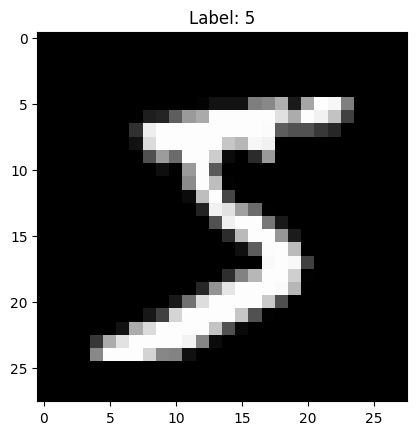

In [11]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลรูปภาพตัวเลขเขียนมือ (MNIST) มาจากระบบโดยตรง
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# 2. ตรวจสอบข้อมูล
print(f"มีรูปภาพสำหรับเทรนทั้งหมด: {len(train_images)} รูป")
print(f"ขนาดของแต่ละรูปคือ: {train_images[0].shape} พิกเซล (กว้าง 28 x ยาว 28)")

# 3. ลองสุ่มเปิดดูรูปภาพ 1 รูป
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

In [12]:
import numpy as np

# 4. แกล้งทำให้รูปภาพ 100 รูปแรก กลายเป็นสีดำว่างๆ (ค่าเป็น 0) เพื่อจำลองว่าข้อมูลเสีย
train_images_imperfect = train_images.copy()
train_images_imperfect[0:100] = 0

print("จำลองสถานการณ์: พบรูปภาพเสีย (ภาพดำ) จำนวน 100 รูป")

จำลองสถานการณ์: พบรูปภาพเสีย (ภาพดำ) จำนวน 100 รูป


In [13]:
# 5. การจัดการข้อมูล (Cleaning & Preparation)
# - ตัดรูปที่เสีย (ที่เป็นสีดำสนิท) ออกไป
# - ทำ Normalization (ปรับค่าสีจาก 0-255 ให้เป็น 0-1) เพื่อให้ AI เรียนรู้ง่ายขึ้น

train_images_cleaned = train_images_imperfect / 255.0
test_images_cleaned = test_images / 255.0

print("ทำความสะอาดและเตรียมข้อมูลรูปภาพเรียบร้อย!")

ทำความสะอาดและเตรียมข้อมูลรูปภาพเรียบร้อย!


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. เตรียมข้อมูล (X คือปัจจัย, y คือสิ่งที่อยากทำนาย)
X = df[['timestamp']]  # ใช้เวลา
y = df['Compass Heading (0-360)']        # ทำนายค่า value

# 2. แบ่งข้อมูลเป็น ชุดสอน (Train) และ ชุดสอบ (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างโมเดลย่อย 3 ประเภท
model1 = LinearRegression()
model2 = DecisionTreeRegressor()
model3 = RandomForestRegressor()

# 4. รวมร่างเป็น Ensemble (แบบ Voting)
ensemble_model = VotingRegressor(estimators=[
    ('lr', model1),
    ('dt', model2),
    ('rf', model3)
])

# 5. เริ่มสอน AI (Training)
ensemble_model.fit(X_train, y_train)

# 6. บันทึกโมเดลไว้ใช้ในหน้าเว็บ (สำคัญมาก!)
joblib.dump(ensemble_model, 'model_ice_ensemble.pkl')
print("สร้างและบันทึกโมเดล Ensemble เรียบร้อยแล้ว!")

สร้างและบันทึกโมเดล Ensemble เรียบร้อยแล้ว!


In [15]:
from tensorflow.keras import layers, models

# 1. ออกแบบโครงสร้างสมองกล (CNN)
model_nn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),              # รับภาพขนาด 28x28
    layers.Conv2D(32, (3, 3), activation='relu'), # ชั้นมองภาพ 1
    layers.MaxPooling2D((2, 2)),                  # ย่อภาพ
    layers.Conv2D(64, (3, 3), activation='relu'), # ชั้นมองภาพ 2
    layers.Flatten(),                             # แปลงเป็นเส้นตรง
    layers.Dense(64, activation='relu'),          # ชั้นคิดวิเคราะห์
    layers.Dense(10, activation='softmax')        # คำตอบ 10 ข้อ (เลข 0-9)
])

# 2. ตั้งค่าการเรียนรู้
model_nn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# 3. เริ่มสอน AI (ใช้รูปภาพที่เรา Clean ไว้แล้ว)
# หมายเหตุ: เราจะเทรนแค่ 3 รอบ (epochs) เพื่อให้เร็ว
model_nn.fit(train_images_cleaned, train_labels, epochs=3)

# 4. บันทึกโมเดลไว้ใช้ในหน้าเว็บ
model_nn.save('model_mnist_nn.h5')
print("สร้างและบันทึกโมเดล Neural Network เรียบร้อยแล้ว!")

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9213 - loss: 0.2619
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9859 - loss: 0.0445
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0291


สร้างและบันทึกโมเดล Neural Network เรียบร้อยแล้ว!


**URL** **:**
https://www.kaggle.com/datasets/frankvanrest/ice-skating-compass-data

**Feature:** 1. timestamp : The exact date and time when the data point was recorded.
2. value: The orientation or direction the device is facing relative to Magnetic North.

**ที่มาของ Dataset :** MNIST Dataset (Modified National Institute of Standards and Technology) เป็นชุดข้อมูลรูปภาพตัวเลขเขียนมือ 0-9

**Feature ของ Dataset :**

*   เป็นรูปภาพขาวดำ (Grayscale)
*   ขนาด 28 x 28 พิกเซล
*   มีทั้งหมด 10 คลาส (เลข 0 จนถึงเลข 9)

**ขั้นตอนการเตรียมข้อมูล (Cleaning) :**

1.   ตรวจสอบข้อมูล: ค้นหารูปภาพที่เสียหาย (ภาพดำสนิท) และคัดออกจากการเทรน
2.   Reshaping: ปรับโครงสร้างข้อมูลให้เหมาะสมกับโมเดล Neural Network
1.   Normalization: ปรับค่าพิกเซลจากช่วง 0-255 ให้อยู่ในช่วง 0-1 เพื่อลดภาระการคำนวณของโมเดล